# NYC Citi Bike — Exploratory Analysis

Loads one month of data into pandas for exploration and plots.
June 2024 is the main sample — good weather, high ridership.
Some sections load extra months for trends and comparisons.

In [18]:
%pip install pandas matplotlib seaborn numpy folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

CSV_DIR = '../csv'
FIG_DIR = '../output/figures'
os.makedirs(FIG_DIR, exist_ok=True)

csv_files = sorted(glob.glob(f'{CSV_DIR}/*.csv'))
print(f'Found {len(csv_files)} CSV files in {CSV_DIR}')
print(f'First few: {[os.path.basename(f) for f in csv_files[:5]]}')

Found 90 CSV files in ../csv
First few: ['202301-citibike-tripdata_1.csv', '202301-citibike-tripdata_2.csv', '202302-citibike-tripdata_1.csv', '202302-citibike-tripdata_2.csv', '202303-citibike-tripdata_1.csv']


## 1. Data Loading

Load June 2024 

In [22]:
# find june 2024
june2024_files = [f for f in csv_files if '202406' in os.path.basename(f)]
if not june2024_files:
    raise FileNotFoundError('No June 2024 file found — run extract.py first')

MAIN_FILE = june2024_files[0]
print(f'Loading {os.path.basename(MAIN_FILE)} ...')

df = pd.read_csv(MAIN_FILE)
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# derived columns
df['duration_secs'] = (df['ended_at'] - df['started_at']).dt.total_seconds()
df['hour'] = df['started_at'].dt.hour
df['day_name'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month
df['is_weekend'] = df['day_name'].isin(['Saturday', 'Sunday'])

# drop bad rows
df = df[df['duration_secs'] > 0]

print(f'Loaded {len(df):,} rides')
print(f'Date range: {df["started_at"].min()} to {df["started_at"].max()}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e9:.1f} GB')
df.head()

Loading 202406-citibike-tripdata_1.csv ...


/var/folders/jj/q0_m984s0yb15v9z1qv47lw00000gn/T/ipykernel_91981/1559184731.py:9: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(MAIN_FILE)


Loaded 1,000,000 rides
Date range: 2024-05-30 23:06:17.842000 to 2024-06-14 19:59:59.748000
Memory: 0.5 GB


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_secs,hour,day_name,month,is_weekend
0,1C6A640ACEFB0795,classic_bike,2024-06-14 08:41:33.060,2024-06-14 08:51:11.113,E 85 St & York Ave,7146.04,E 63 St & 3 Ave,6830.02,40.775369,-73.948034,40.763954,-73.964600,member,578.053,8,Friday,6,False
1,6982C5274D493834,electric_bike,2024-06-13 20:11:55.677,2024-06-13 20:18:51.570,6 Ave & Broome St,5610.09,Bank St & Washington St,5964.01,40.724310,-74.004730,40.736197,-74.008592,member,415.893,20,Thursday,6,False
2,235EDC45BD2151E4,electric_bike,2024-06-12 12:44:45.109,2024-06-12 12:55:27.631,6 Ave & Broome St,5610.09,E 17 St & 2 Ave,5896.01,40.724310,-74.004730,40.734312,-73.983725,member,642.522,12,Wednesday,6,False
3,62586586291415AC,classic_bike,2024-06-11 12:59:14.679,2024-06-11 13:20:40.846,Fulton St & Waverly Ave,4345.11,Atlantic Ave & Furman St,4614.04,40.683239,-73.965996,40.691652,-73.999979,member,1286.167,12,Tuesday,6,False
4,746A5E2469FB7DD9,electric_bike,2024-06-11 19:14:36.519,2024-06-11 19:37:54.512,Carlton Ave & Dean St,4199.12,Canal St & Rutgers St,5303.08,40.680974,-73.971010,40.714275,-73.989900,member,1397.993,19,Tuesday,6,False


## 2. Overview Stats

Total rides: 1,000,000
Unique start stations: 2145
Unique end stations: 1765

Member vs Casual:
member_casual
member    773030
casual    226970
Name: count, dtype: int64

Bike types:
rideable_type
electric_bike    627679
classic_bike     372321
Name: count, dtype: int64

Avg trip duration: 16.1 min
Median trip duration: 10.0 min


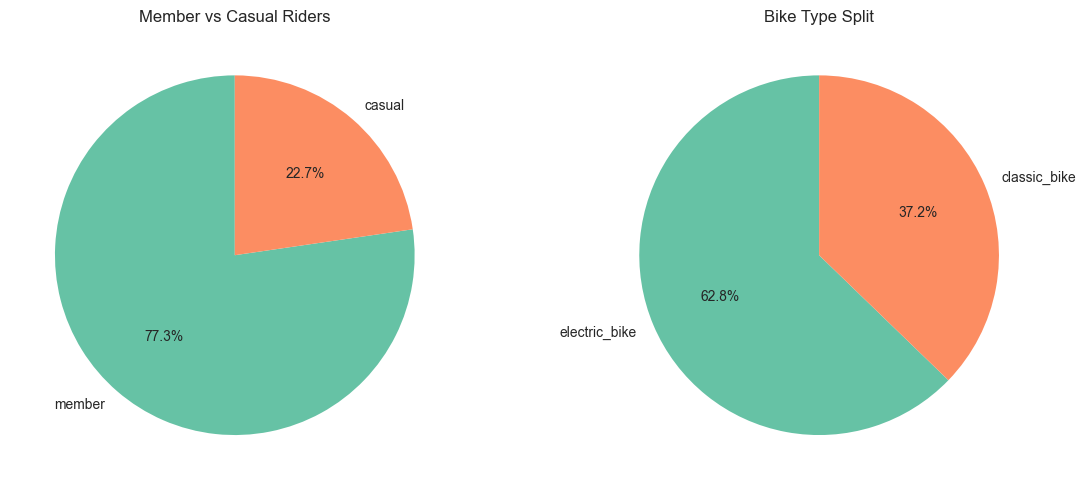

In [8]:
total_rides = len(df)
unique_start = df['start_station_name'].nunique()
unique_end = df['end_station_name'].nunique()

print(f'Total rides: {total_rides:,}')
print(f'Unique start stations: {unique_start}')
print(f'Unique end stations: {unique_end}')

member_counts = df['member_casual'].value_counts()
print(f'\nMember vs Casual:\n{member_counts}')

bike_counts = df['rideable_type'].value_counts()
print(f'\nBike types:\n{bike_counts}')

avg_dur = df['duration_secs'].mean() / 60
med_dur = df['duration_secs'].median() / 60
print(f'\nAvg trip duration: {avg_dur:.1f} min')
print(f'Median trip duration: {med_dur:.1f} min')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.pie(member_counts.values, labels=member_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Member vs Casual Riders')

ax2.pie(bike_counts.values, labels=bike_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Bike Type Split')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/overview_pies.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Popular Stations

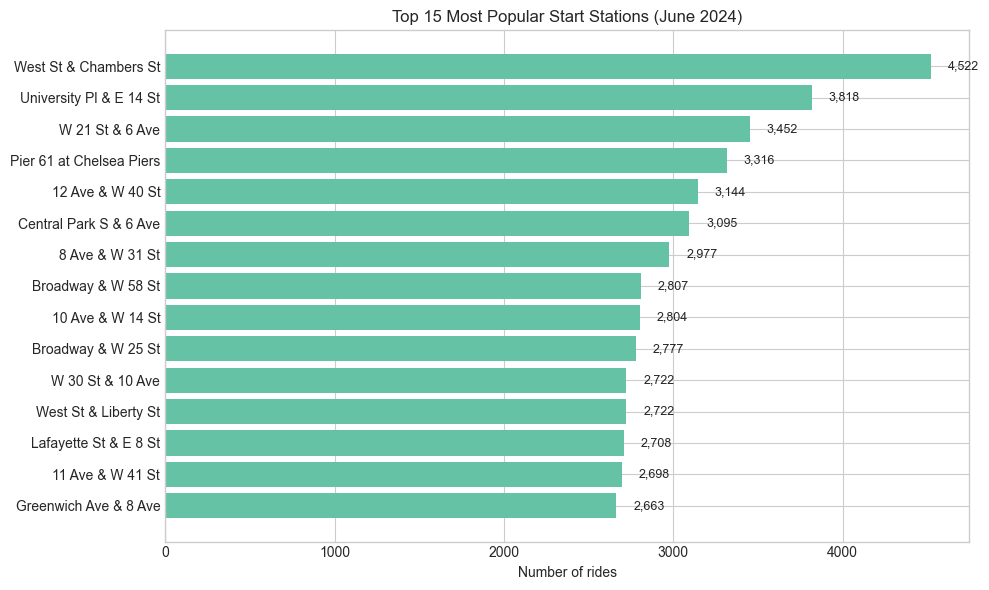

In [9]:
top_stations = df['start_station_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_stations)), top_stations.values, color=sns.color_palette('Set2')[0])
ax.set_yticks(range(len(top_stations)))
ax.set_yticklabels(top_stations.index)
ax.invert_yaxis()
ax.set_xlabel('Number of rides')
ax.set_title('Top 15 Most Popular Start Stations (June 2024)')

# add count labels
for i, v in enumerate(top_stations.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/popular_stations.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Bike Type Trends

Compare e-bike vs classic across 2 years at 6-month intervals to see adoption trend.

202301: classic=489,257, electric=510,743 (51.1% electric)
202306: classic=591,822, electric=408,178 (40.8% electric)
202401: classic=358,660, electric=641,340 (64.1% electric)
202406: classic=372,321, electric=627,679 (62.8% electric)


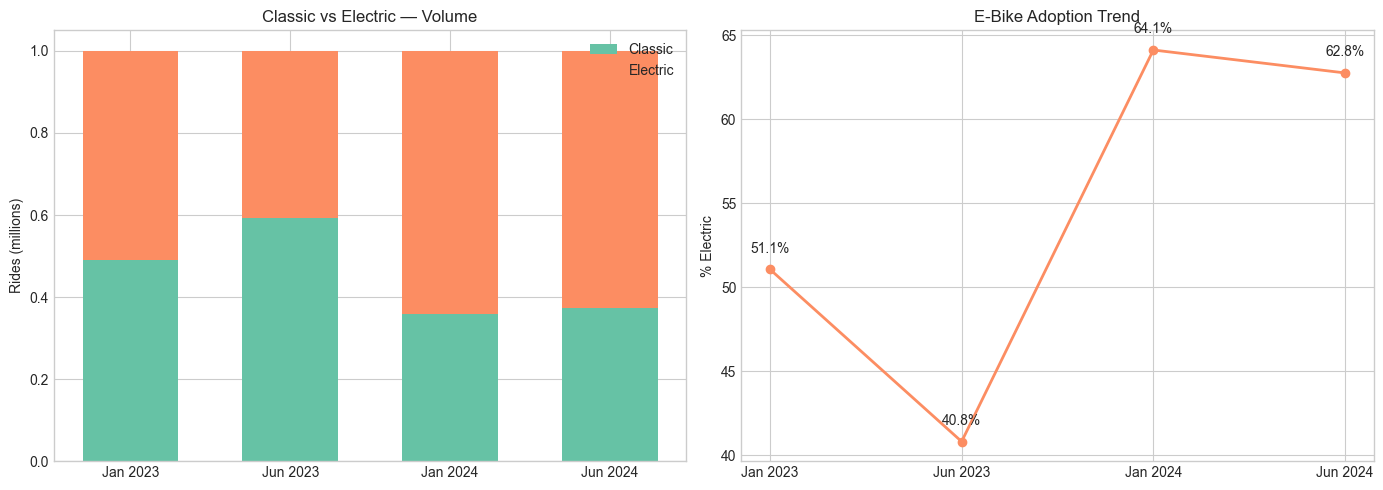

In [23]:
# compare every 6 months: Jan 2023, Jun 2023, Jan 2024, Jun 2024
timepoints = ['202301', '202306', '202401', '202406']
labels = ['Jan 2023', 'Jun 2023', 'Jan 2024', 'Jun 2024']
type_data = []

for m in timepoints:
    matches = [f for f in csv_files if m in os.path.basename(f)]
    if not matches:
        print(f'{m} — not found, skipping')
        continue
    tmp = pd.read_csv(matches[0], usecols=['rideable_type'])
    classic = (tmp['rideable_type'] == 'classic_bike').sum()
    electric = (tmp['rideable_type'] == 'electric_bike').sum()
    pct_elec = electric / (classic + electric) * 100
    type_data.append({'month': m, 'classic': classic, 'electric': electric, 'pct_electric': pct_elec})
    print(f'{m}: classic={classic:,}, electric={electric:,} ({pct_elec:.1f}% electric)')

tdf = pd.DataFrame(type_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: stacked bar — absolute numbers
x = np.arange(len(tdf))
w = 0.6
ax1.bar(x, tdf['classic'] / 1e6, w, label='Classic', color=sns.color_palette('Set2')[0])
ax1.bar(x, tdf['electric'] / 1e6, w, bottom=tdf['classic'] / 1e6, label='Electric', color=sns.color_palette('Set2')[1])
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Rides (millions)')
ax1.set_title('Classic vs Electric — Volume')
ax1.legend()

# plot 2: e-bike percentage trend
ax2.plot(labels, tdf['pct_electric'].values, marker='o', linewidth=2, color=sns.color_palette('Set2')[1])
ax2.set_ylabel('% Electric')
ax2.set_title('E-Bike Adoption Trend')
for i, pct in enumerate(tdf['pct_electric'].values):
    ax2.annotate(f'{pct:.1f}%', (labels[i], pct), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/bike_type_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. User Patterns

Member vs casual: when do they ride and how long?

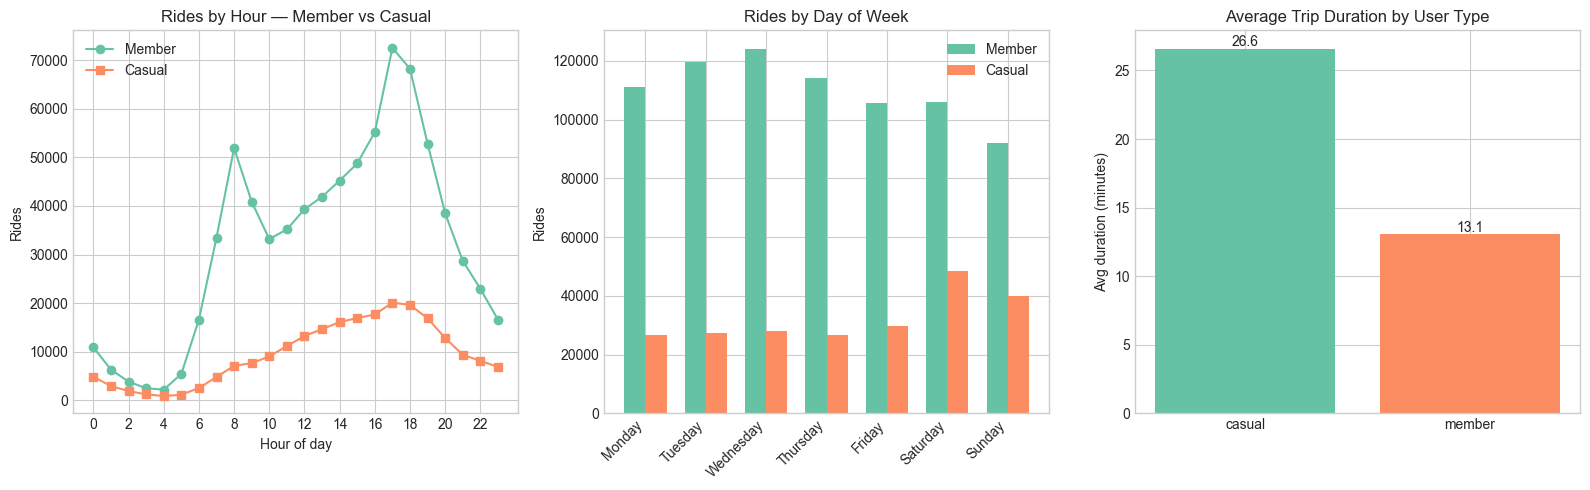

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# plot 1: rides by hour
hourly = df.groupby(['hour', 'member_casual']).size().unstack()
axes[0].plot(hourly.index, hourly['member'], marker='o', label='Member')
axes[0].plot(hourly.index, hourly['casual'], marker='s', label='Casual')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Rides')
axes[0].set_title('Rides by Hour — Member vs Casual')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

# plot 2: rides by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df.groupby(['day_name', 'member_casual']).size().unstack().reindex(day_order)
x = np.arange(len(day_order))
w = 0.35
axes[1].bar(x - w/2, daily['member'], w, label='Member', color=sns.color_palette('Set2')[0])
axes[1].bar(x + w/2, daily['casual'], w, label='Casual', color=sns.color_palette('Set2')[1])
axes[1].set_xticks(x)
axes[1].set_xticklabels(day_order, rotation=45, ha='right')
axes[1].set_ylabel('Rides')
axes[1].set_title('Rides by Day of Week')
axes[1].legend()

# plot 3: avg duration
avg_dur = df.groupby('member_casual')['duration_secs'].mean() / 60
bars = axes[2].bar(avg_dur.index, avg_dur.values, color=[sns.color_palette('Set2')[0], sns.color_palette('Set2')[1]])
axes[2].set_ylabel('Avg duration (minutes)')
axes[2].set_title('Average Trip Duration by User Type')
for bar, val in zip(bars, avg_dur.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/user_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Trip Duration Distribution

/var/folders/jj/q0_m984s0yb15v9z1qv47lw00000gn/T/ipykernel_91981/3158630571.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([classic_dur.clip(upper=upper_value), electric_dur.clip(upper=upper_value)],


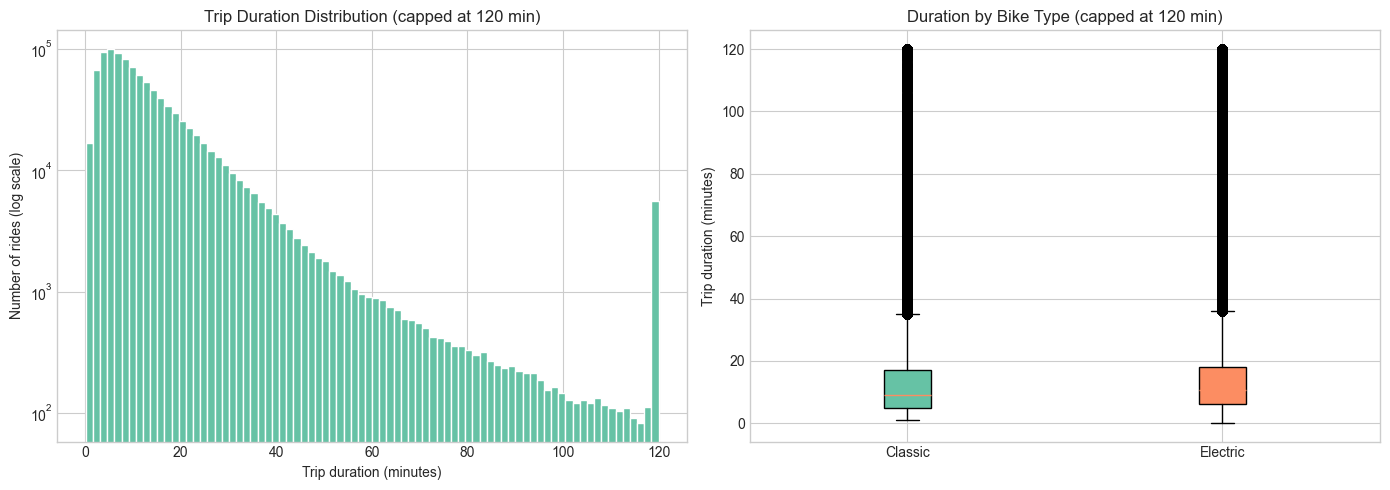

Duration stats (minutes):
count    1000000.000000
mean          16.129550
std           48.297100
min            0.106417
25%            5.671150
50%           10.042025
75%           17.686100
max         1501.578183
Name: duration_secs, dtype: float64


In [29]:
upper_value = 120
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# histogram with log y-scale
durations_min = df['duration_secs'] / 60
ax1.hist(durations_min.clip(upper=upper_value), bins=80, color=sns.color_palette('Set2')[0], edgecolor='white')
ax1.set_xlabel('Trip duration (minutes)')
ax1.set_ylabel('Number of rides (log scale)')
ax1.set_title('Trip Duration Distribution (capped at 120 min)')
ax1.set_yscale('log')

# boxplot by bike type
classic_dur = df[df['rideable_type'] == 'classic_bike']['duration_secs'] / 60
electric_dur = df[df['rideable_type'] == 'electric_bike']['duration_secs'] / 60
bp = ax2.boxplot([classic_dur.clip(upper=upper_value), electric_dur.clip(upper=upper_value)], 
                 labels=['Classic', 'Electric'], patch_artist=True)
for patch, color in zip(bp['boxes'], [sns.color_palette('Set2')[0], sns.color_palette('Set2')[1]]):
    patch.set_facecolor(color)
ax2.set_ylabel('Trip duration (minutes)')
ax2.set_title('Duration by Bike Type (capped at 120 min)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/trip_durations.png', dpi=150, bbox_inches='tight')
plt.show()

# print some stats
print('Duration stats (minutes):')
print(durations_min.describe())

### What's up with rides over 1000 minutes?

16+ hours seems odd for a bike share. Are these lost bikes, system errors, or something else?

Rides over 1000 min: 791 out of 1,000,000 (0.08%)
Rides over 24h (1440 min): 678

Long ride duration stats:
count      791.000000
mean     87244.228167
std       7247.488400
min      60276.328000
25%      89979.947000
50%      89992.556000
75%      89994.618000
max      90094.691000
Name: duration_secs, dtype: float64

User type split:
member_casual
casual    450
member    341
Name: count, dtype: int64

vs overall:
member_casual
member    77.3
casual    22.7
Name: proportion, dtype: float64

Bike type:
rideable_type
classic_bike     743
electric_bike     48
Name: count, dtype: int64

Day of week:
day_name
Friday       168
Saturday     142
Thursday     122
Sunday       106
Tuesday      104
Monday        77
Wednesday     72
Name: count, dtype: int64

Start hour distribution:
hour
0     26
1     10
2      6
3     13
4      3
5      3
6     13
7     17
8     30
9     26
10    27
11    42
12    30
13    43
14    58
15    63
16    58
17    60
18    70
19    55
20    34
21    33
22    37
23  

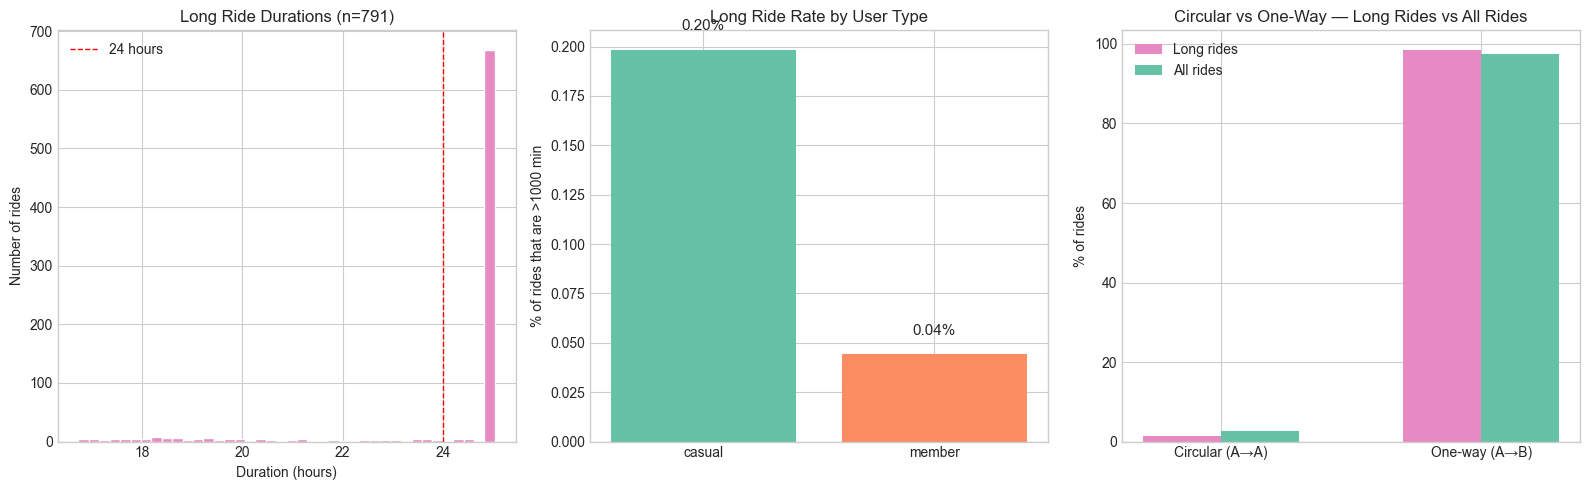

In [32]:
# investigate very long rides
long_rides = df[df['duration_secs'] > 1000 * 60].copy()
print(f'Rides over 1000 min: {len(long_rides):,} out of {len(df):,} ({len(long_rides)/len(df)*100:.2f}%)')
print(f'Rides over 24h (1440 min): {(df["duration_secs"] > 1440*60).sum():,}')

# duration stats for long rides
print(f'\nLong ride duration stats:')
print(long_rides['duration_secs'].describe())

# member vs casual
print(f'\nUser type split:')
print(long_rides['member_casual'].value_counts())
print(f'\nvs overall:')
print(df['member_casual'].value_counts(normalize=True).mul(100).round(1))

# bike type
print(f'\nBike type:')
print(long_rides['rideable_type'].value_counts())

# day of week
print(f'\nDay of week:')
print(long_rides['day_name'].value_counts())

# hour started
print(f'\nStart hour distribution:')
print(long_rides['hour'].value_counts().sort_index())

# are these mostly circular trips?
long_circular = (long_rides['start_station_name'] == long_rides['end_station_name']).sum()
long_pct_circ = long_circular / len(long_rides) * 100
print(f'\nCircular among long rides: {long_circular:,} ({long_pct_circ:.1f}%)')
print(f'Circular among all rides: {(df["start_station_name"] == df["end_station_name"]).sum():,} ({(df["start_station_name"] == df["end_station_name"]).sum()/len(df)*100:.1f}%)')

# ---- plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# plot 1: histogram of long ride durations (in hours)
long_hours = long_rides['duration_secs'] / 3600
axes[0].hist(long_hours, bins=40, color=sns.color_palette('Set2')[3], edgecolor='white')
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Number of rides')
axes[0].set_title(f'Long Ride Durations (n={len(long_rides):,})')
axes[0].axvline(24, color='red', linestyle='--', linewidth=1, label='24 hours')
axes[0].legend()

# plot 2: user type comparison
long_by_type = long_rides['member_casual'].value_counts()
all_by_type = df['member_casual'].value_counts()
pct_long = long_by_type / all_by_type * 100
bars = axes[1].bar(pct_long.index, pct_long.values, color=[sns.color_palette('Set2')[0], sns.color_palette('Set2')[1]])
axes[1].set_ylabel('% of rides that are >1000 min')
axes[1].set_title('Long Ride Rate by User Type')
for bar, val in zip(bars, pct_long.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.2f}%', ha='center', fontsize=11)

# plot 3: circular vs one-way in long rides
long_circ_counts = [long_circular, len(long_rides) - long_circular]
all_circ = (df['start_station_name'] == df['end_station_name']).sum()
all_circ_counts = [all_circ, len(df) - all_circ]
x = np.arange(2)
w = 0.3
axes[2].bar(x - w/2, [c/len(long_rides)*100 for c in long_circ_counts], w, label='Long rides', color=sns.color_palette('Set2')[3])
axes[2].bar(x + w/2, [c/len(df)*100 for c in all_circ_counts], w, label='All rides', color=sns.color_palette('Set2')[0])
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Circular (A→A)', 'One-way (A→B)'])
axes[2].set_ylabel('% of rides')
axes[2].set_title('Circular vs One-Way — Long Rides vs All Rides')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/long_rides.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Peak Hours

Compare weekday vs weekend riding patterns.

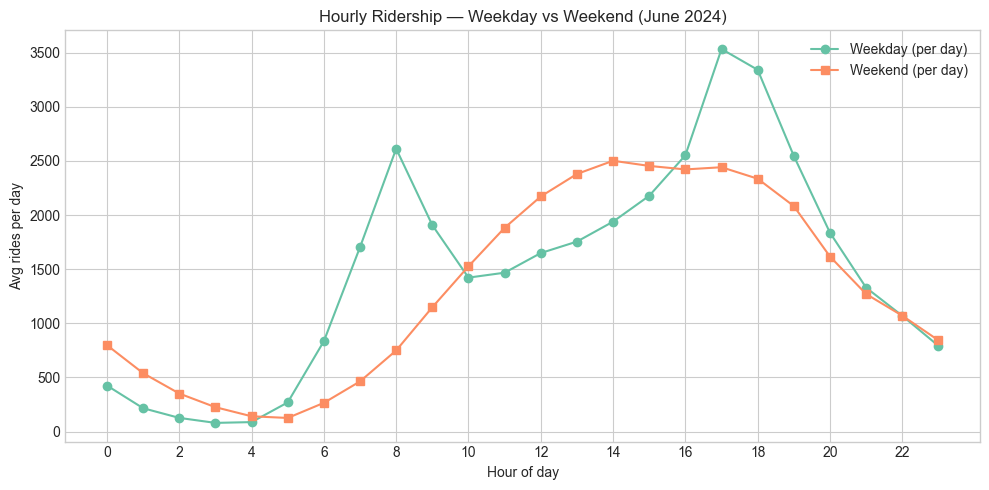

In [13]:
weekday_hourly = df[~df['is_weekend']].groupby('hour').size()
weekend_hourly = df[df['is_weekend']].groupby('hour').size()

# normalize to rides per day
weekday_hourly_norm = weekday_hourly / 20  # ~20 weekdays in june
weekend_hourly_norm = weekend_hourly / 9   # ~9 weekend days

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weekday_hourly_norm.index, weekday_hourly_norm.values, marker='o', label='Weekday (per day)')
ax.plot(weekend_hourly_norm.index, weekend_hourly_norm.values, marker='s', label='Weekend (per day)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg rides per day')
ax.set_title('Hourly Ridership — Weekday vs Weekend (June 2024)')
ax.legend()
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/peak_hours.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Top Routes

Most popular station-to-station pairs.

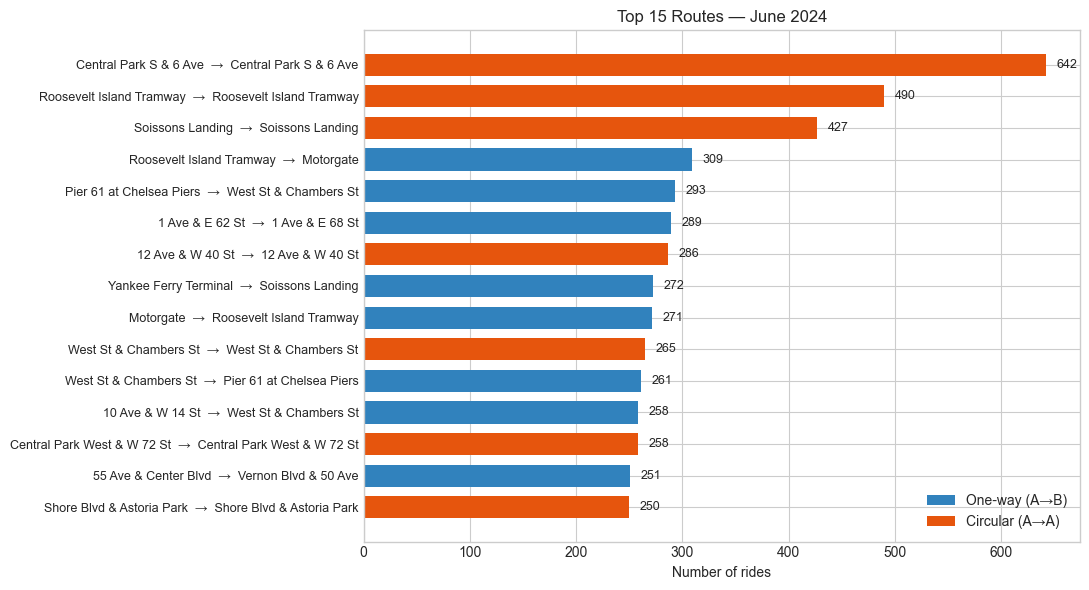

In [44]:
routes = df.groupby(['start_station_name', 'end_station_name']).size().reset_index(name='count')
top_routes = routes.nlargest(15, 'count').copy()

# mark circular routes (A->A)
top_routes['is_circular'] = top_routes['start_station_name'] == top_routes['end_station_name']
top_routes['label'] = top_routes.apply(
    lambda r: f"{r['start_station_name']}  →  {r['end_station_name']}", axis=1)

# split for coloring
colors = ['#e6550d' if c else '#3182bd' for c in top_routes['is_circular']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(range(len(top_routes)), top_routes['count'].values, color=colors, height=0.7)
ax.set_yticks(range(len(top_routes)))
ax.set_yticklabels(top_routes['label'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of rides')
ax.set_title('Top 15 Routes — June 2024')

# add count labels
for i, (v, is_circ) in enumerate(zip(top_routes['count'].values, top_routes['is_circular'])):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3182bd', label='One-way (A→B)'),
    Patch(facecolor='#e6550d', label='Circular (A→A)')
]
ax.legend(handles=legend_elements, loc='lower right')


plt.tight_layout()
plt.savefig(f'{FIG_DIR}/top_routes.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Seasonal Trends

Ride volume across all months in 2024. Load each month one at a time to save memory.

Counting 202401 ...
Counting 202401 ...
Counting 202402 ...
Counting 202402 ...
Counting 202402 ...
Counting 202403 ...
Counting 202403 ...
Counting 202403 ...
Counting 202404 ...
Counting 202404 ...
Counting 202404 ...
Counting 202404 ...
Counting 202405 ...
Counting 202405 ...
Counting 202405 ...
Counting 202405 ...
Counting 202405 ...
Counting 202406 ...
Counting 202406 ...
Counting 202406 ...
Counting 202406 ...
Counting 202406 ...
Counting 202407 ...
Counting 202407 ...
Counting 202407 ...
Counting 202407 ...
Counting 202407 ...
Counting 202408 ...
Counting 202408 ...
Counting 202408 ...
Counting 202408 ...
Counting 202408 ...
Counting 202409 ...
Counting 202409 ...
Counting 202409 ...
Counting 202409 ...
Counting 202409 ...
Counting 202410 ...
Counting 202410 ...
Counting 202410 ...
Counting 202410 ...
Counting 202410 ...
Counting 202410 ...
Counting 202411 ...
Counting 202411 ...
Counting 202411 ...
Counting 202411 ...
Counting 202412 ...
Counting 202412 ...
Counting 202412 ...


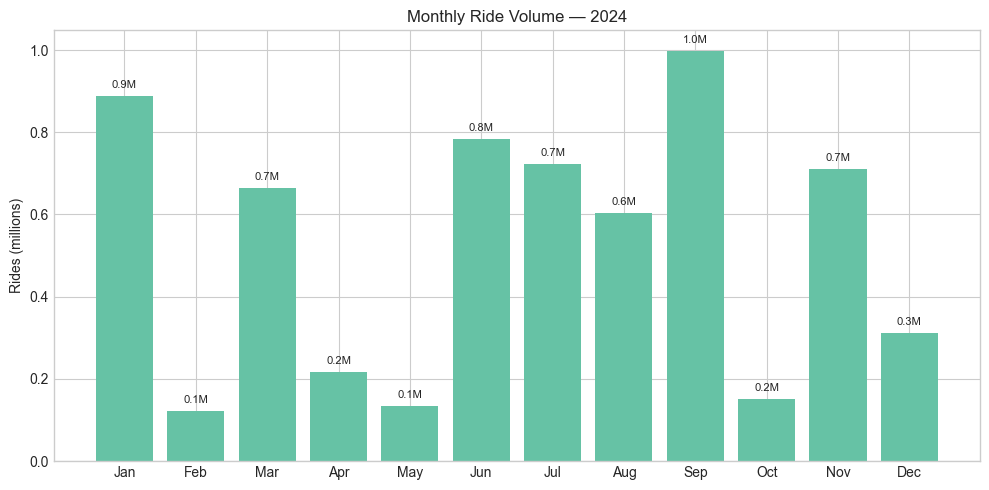

In [15]:
# count rides per month (only read ride_id column, way faster)
monthly_counts = {}

for f in sorted(csv_files):
    basename = os.path.basename(f)
    if '2024' not in basename:
        continue
    # extract month number from filename
    month_str = basename[:6]
    if not month_str.isdigit():
        continue
    month_num = int(month_str[4:6])
    print(f'Counting {month_str} ...')
    tmp = pd.read_csv(f, usecols=['ride_id'])
    monthly_counts[month_num] = len(tmp)

months_sorted = sorted(monthly_counts.keys())
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
counts_list = [monthly_counts[m] for m in months_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(months_sorted, [c/1e6 for c in counts_list], color=sns.color_palette('Set2')[0])
ax.set_xticks(months_sorted)
ax.set_xticklabels([month_names[m-1] for m in months_sorted])
ax.set_ylabel('Rides (millions)')
ax.set_title('Monthly Ride Volume — 2024')

for bar, val in zip(bars, counts_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val/1e6:.1f}M', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/seasonal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Year-over-Year Comparison

Same month (June) in 2023 vs 2024.

June 2023: 1,000,000 rides (member: 805,472, casual: 194,528)
June 2024: 1,000,000 rides (member: 773,030, casual: 226,970)
Growth: +0.0%


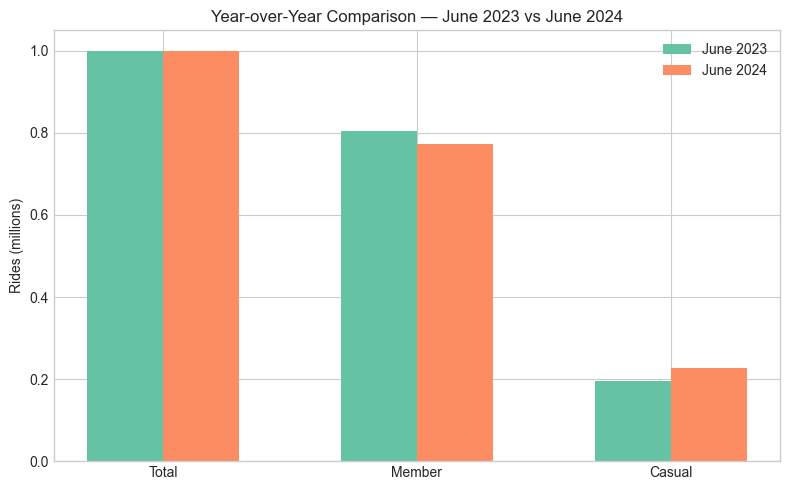

In [16]:
def count_rides_in_month(file_pattern):
    matches = [f for f in csv_files if file_pattern in os.path.basename(f)]
    if not matches:
        print(f'No file matching {file_pattern}')
        return 0, 0, 0
    df_tmp = pd.read_csv(matches[0], usecols=['ride_id', 'member_casual', 'rideable_type'])
    total = len(df_tmp)
    members = (df_tmp['member_casual'] == 'member').sum()
    casuals = (df_tmp['member_casual'] == 'casual').sum()
    return total, members, casuals

june2023_total, june2023_member, june2023_casual = count_rides_in_month('202306')
june2024_total, june2024_member, june2024_casual = count_rides_in_month('202406')

print(f'June 2023: {june2023_total:,} rides (member: {june2023_member:,}, casual: {june2023_casual:,})')
print(f'June 2024: {june2024_total:,} rides (member: {june2024_member:,}, casual: {june2024_casual:,})')

if june2023_total > 0:
    growth = (june2024_total - june2023_total) / june2023_total * 100
    print(f'Growth: {growth:+.1f}%')

fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Total', 'Member', 'Casual']
values_2023 = [june2023_total, june2023_member, june2023_casual]
values_2024 = [june2024_total, june2024_member, june2024_casual]

x = np.arange(len(categories))
w = 0.3
ax.bar(x - w/2, [v/1e6 for v in values_2023], w, label='June 2023', color=sns.color_palette('Set2')[0])
ax.bar(x + w/2, [v/1e6 for v in values_2024], w, label='June 2024', color=sns.color_palette('Set2')[1])
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Rides (millions)')
ax.set_title('Year-over-Year Comparison — June 2023 vs June 2024')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/yoy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Recommendation System Preview

Compute net bike inflow per station for a given hour.
Stations with more trips ending than starting at that hour likely have bikes available.


--- Hour 8:00 ---
Top 10 stations to find a bike:
  Greenwich St & Hubert St: +526 net inflow (starts=42, ends=568)
  1 Ave & E 68 St: +448 net inflow (starts=214, ends=662)
  E 40 St & Park Ave: +434 net inflow (starts=184, ends=618)
  West St & Chambers St: +385 net inflow (starts=195, ends=580)
  E 48 St & 5 Ave: +345 net inflow (starts=44, ends=389)
  8 Ave & W 31 St: +337 net inflow (starts=173, ends=510)
  E 43 St & Madison Ave: +319 net inflow (starts=179, ends=498)
  E 53 St & 3 Ave: +310 net inflow (starts=78, ends=388)
  Broadway & W 51 St: +302 net inflow (starts=153, ends=455)
  Broadway & W 48 St: +300 net inflow (starts=107, ends=407)


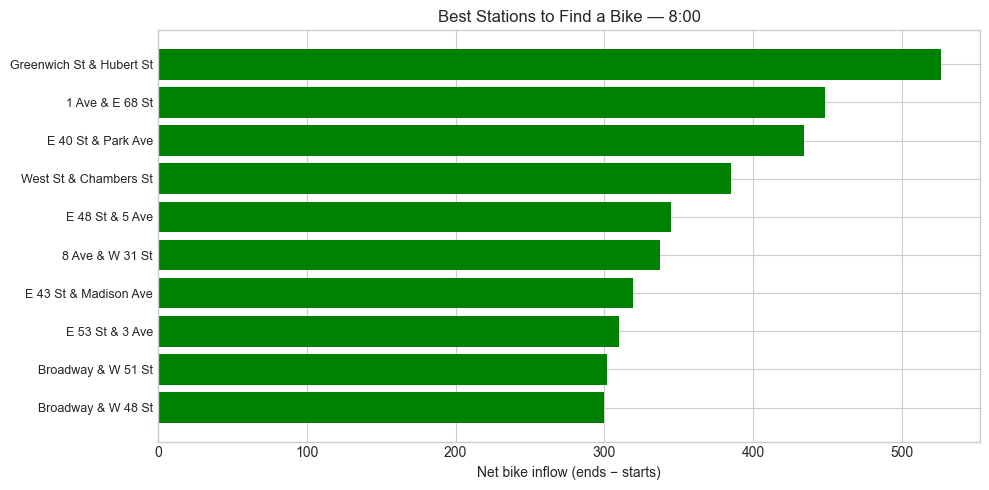


--- Hour 17:00 ---
Top 10 stations to find a bike:
  12 Ave & W 40 St: +635 net inflow (starts=282, ends=917)
  Pier 61 at Chelsea Piers: +426 net inflow (starts=360, ends=786)
  University Pl & E 14 St: +423 net inflow (starts=342, ends=765)
  Riverside Blvd & W 67 St: +406 net inflow (starts=180, ends=586)
  8 Ave & W 31 St: +395 net inflow (starts=332, ends=727)
  W 43 St & 10 Ave: +387 net inflow (starts=172, ends=559)
  Amsterdam Ave & W 73 St: +369 net inflow (starts=172, ends=541)
  Columbus Ave & W 72 St: +309 net inflow (starts=183, ends=492)
  West St & Chambers St: +308 net inflow (starts=536, ends=844)
  W 24 St & 7 Ave: +307 net inflow (starts=179, ends=486)


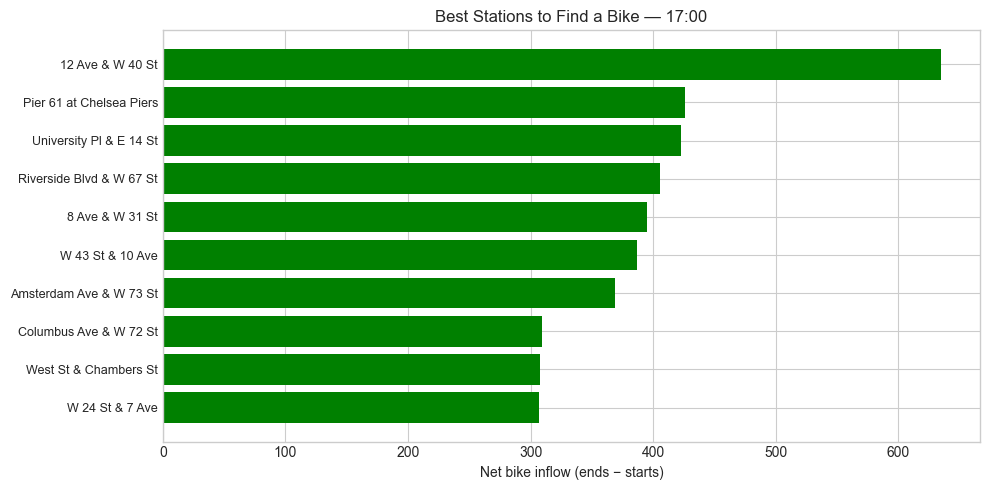

In [17]:
# pick two interesting hours: morning commute (8am) and evening (5pm)
for check_hour in [8, 17]:
    print(f'\n--- Hour {check_hour}:00 ---')
    
    starts = df[df['hour'] == check_hour].groupby('start_station_name').size().reset_index(name='starts')
    
    end_hour = df['ended_at'].dt.hour
    ends = df[end_hour == check_hour].groupby('end_station_name').size().reset_index(name='ends')
    
    net = starts.merge(ends, left_on='start_station_name', right_on='end_station_name', how='outer').fillna(0)
    net['station'] = net['start_station_name'].where(net['start_station_name'] != 0, net['end_station_name'])
    net['net_inflow'] = net['ends'] - net['starts']
    net['total_activity'] = net['starts'] + net['ends']
    
    # filter to stations with decent activity
    active = net[net['total_activity'] > 50].copy()
    top_stations = active.nlargest(10, 'net_inflow')
    
    print('Top 10 stations to find a bike:')
    for _, row in top_stations.iterrows():
        print(f'  {row["station"]}: +{row["net_inflow"]:.0f} net inflow (starts={row["starts"]:.0f}, ends={row["ends"]:.0f})')
    
    # plot
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['green' if v > 0 else 'red' for v in top_stations['net_inflow'].values]
    ax.barh(range(len(top_stations)), top_stations['net_inflow'].values, color=colors)
    ax.set_yticks(range(len(top_stations)))
    ax.set_yticklabels([s[:40] for s in top_stations['station'].values], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Net bike inflow (ends − starts)')
    ax.set_title(f'Best Stations to Find a Bike — {check_hour}:00')
    ax.axvline(0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/recommend_hour{check_hour}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 12. Station Map

Top stations plotted on an interactive map. Circle size = number of rides starting there.

In [19]:
import folium

# get top 40 stations with coordinates
station_stats = df.groupby('start_station_name').agg(
    rides=('ride_id', 'count'),
    lat=('start_lat', 'first'),
    lng=('start_lng', 'first')
).nlargest(40, 'rides').reset_index()

# center map on manhattan
m = folium.Map(location=[40.73, -73.99], zoom_start=12, tiles='CartoDB positron')

# scale circles — biggest station gets radius 30, smallest ~5
max_rides = station_stats['rides'].max()
min_rides = station_stats['rides'].min()

for _, row in station_stats.iterrows():
    radius = 5 + (row['rides'] - min_rides) / (max_rides - min_rides) * 25
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=radius,
        popup=f"{row['start_station_name']}<br>{row['rides']:,} rides",
        color='#3182bd',
        fill=True,
        fill_color='#3182bd',
        fill_opacity=0.3,
        weight=1
    ).add_to(m)

m.save(f'{FIG_DIR}/station_map.html')
print(f'Plotted {len(station_stats)} stations')
m

Plotted 40 stations


## 13. Top Routes on Map

Top station-to-station routes drawn as lines. Thicker line = more popular.

In [45]:
# top 20 routes with coordinates
route_counts = df.groupby(['start_station_name', 'end_station_name',
                            'start_lat', 'start_lng', 'end_lat', 'end_lng']).size().reset_index(name='count')
top_routes_geo = route_counts.nlargest(20, 'count').copy()
top_routes_geo['is_circular'] = top_routes_geo['start_station_name'] == top_routes_geo['end_station_name']

# split
circular = top_routes_geo[top_routes_geo['is_circular']]
oneway = top_routes_geo[~top_routes_geo['is_circular']]

m2 = folium.Map(location=[40.73, -73.99], zoom_start=12, tiles='CartoDB positron')

# ---- A->B routes: draw as lines ----
if len(oneway) > 0:
    max_count = oneway['count'].max()
    min_count = oneway['count'].min()
    
    for _, row in oneway.iterrows():
        weight = 1 + (row['count'] - min_count) / (max_count - min_count) * 5
        folium.PolyLine(
            locations=[[row['start_lat'], row['start_lng']], [row['end_lat'], row['end_lng']]],
            weight=weight,
            color='#3182bd',
            opacity=0.6,
            popup=f"{row['start_station_name']} → {row['end_station_name']}<br>{row['count']:,} rides"
        ).add_to(m2)

# ---- A->A routes: draw as circle markers ----
if len(circular) > 0:
    max_circ = circular['count'].max()
    min_circ = circular['count'].min()
    
    for _, row in circular.iterrows():
        radius = 6 + (row['count'] - min_circ) / (max_circ - min_circ) * 20
        folium.CircleMarker(
            location=[row['start_lat'], row['start_lng']],
            radius=radius,
            popup=f"↺ {row['start_station_name']}<br>{row['count']:,} circular rides",
            color='#e6550d',
            fill=True,
            fill_color='#e6550d',
            fill_opacity=0.25,
            weight=2
        ).add_to(m2)

# legend
legend_html = '''
<div style="position:fixed; bottom:20px; left:20px; z-index:9999; background:white; padding:10px; border-radius:5px; box-shadow:0 1px 4px rgba(0,0,0,0.2); font-size:13px;">
<b>Top 20 Routes</b><br>
<span style="color:#3182bd;">━━━</span> One-way (A→B)<br>
<span style="color:#e6550d;">●</span> Circular (A→A)
</div>
'''
m2.get_root().html.add_child(folium.Element(legend_html))

m2.save(f'{FIG_DIR}/route_map.html')
print(f'Plotted {len(oneway)} one-way routes + {len(circular)} circular hubs')
m2


Plotted 12 one-way routes + 8 circular hubs


## 14. Circular Trips (A → A)

Lots of top routes start and end at the same station. These are likely leisure / exercise rides.
Let's compare them to one-way trips.

Circular trips (A→A): 25,881 (2.6%)
One-way trips (A→B):  974,119 (97.4%)
Avg circular duration: 25.3 min
Avg one-way duration:  15.9 min
Median circular duration: 14.8 min
Median one-way duration:  10.0 min

Circular trip split:\nmember_casual
member    13994
casual    11887
Name: count, dtype: int64
\nCircular: 45.9% casual vs overall 22.7% casual
\nTop circular-trip stations:
  Central Park S & 6 Ave: 642 circular out of 3,095 rides (21%)
  Roosevelt Island Tramway: 490 circular out of 991 rides (49%)
  Soissons Landing: 427 circular out of 445 rides (96%)
  12 Ave & W 40 St: 286 circular out of 3,144 rides (9%)
  West St & Chambers St: 265 circular out of 4,522 rides (6%)
  Central Park West & W 72 St: 258 circular out of 1,649 rides (16%)
  Shore Blvd & Astoria Park: 250 circular out of 596 rides (42%)
  Grand Army Plaza & Central Park S: 236 circular out of 1,668 rides (14%)
  Central Park North & Adam Clayton Powell Blvd: 226 circular out of 1,350 rides (17%)
  Pier 61 at Chelse

/var/folders/jj/q0_m984s0yb15v9z1qv47lw00000gn/T/ipykernel_91981/1919140062.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([d.clip(upper=90) for d in bp_data], labels=['One-way', 'Circular (A→A)'], patch_artist=True)


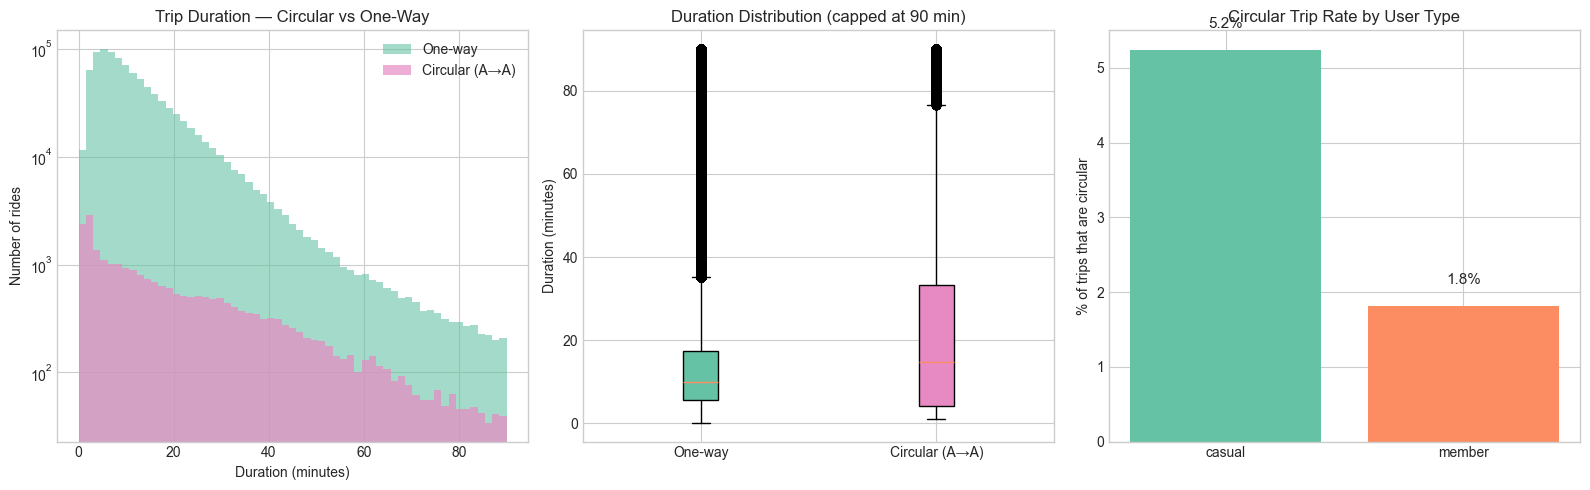

In [34]:
# split trips into circular (A->A) and one-way (A->B)
circular = df[df['start_station_name'] == df['end_station_name']]
oneway = df[df['start_station_name'] != df['end_station_name']]

pct_circular = len(circular) / len(df) * 100
print(f'Circular trips (A→A): {len(circular):,} ({pct_circular:.1f}%)')
print(f'One-way trips (A→B):  {len(oneway):,} ({100-pct_circular:.1f}%)')
print(f'Avg circular duration: {circular["duration_secs"].mean()/60:.1f} min')
print(f'Avg one-way duration:  {oneway["duration_secs"].mean()/60:.1f} min')
print(f'Median circular duration: {circular["duration_secs"].median()/60:.1f} min')
print(f'Median one-way duration:  {oneway["duration_secs"].median()/60:.1f} min')

# which user type does more circular trips?
circ_by_type = circular['member_casual'].value_counts()
circ_pct_by_type = circular['member_casual'].value_counts(normalize=True) * 100
all_pct_by_type = df['member_casual'].value_counts(normalize=True) * 100
print(f'\nCircular trip split:\\n{circ_by_type}')
print(f'\\nCircular: {circ_pct_by_type["casual"]:.1f}% casual vs overall {all_pct_by_type["casual"]:.1f}% casual')

# top stations for circular trips
top_circular_stations = circular['start_station_name'].value_counts().head(10)
print(f'\\nTop circular-trip stations:')
for station, count in top_circular_stations.items():
    total_at_station = (df['start_station_name'] == station).sum()
    pct = count / total_at_station * 100
    print(f'  {station}: {count:,} circular out of {total_at_station:,} rides ({pct:.0f}%)')

# ---- plots ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# plot 1: duration histogram overlay (capped at 90 min)
bins = np.linspace(0, 90, 60)
axes[0].hist(oneway['duration_secs']/60, bins=bins, alpha=0.6, label='One-way', color=sns.color_palette('Set2')[0])
axes[0].hist(circular['duration_secs']/60, bins=bins, alpha=0.7, label='Circular (A→A)', color=sns.color_palette('Set2')[3])
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Number of rides')
axes[0].set_title('Trip Duration — Circular vs One-Way')
axes[0].legend()
axes[0].set_yscale('log')

# plot 2: boxplot comparison
bp_data = [oneway['duration_secs']/60, circular['duration_secs']/60]
bp = axes[1].boxplot([d.clip(upper=90) for d in bp_data], labels=['One-way', 'Circular (A→A)'], patch_artist=True)
for patch, color in zip(bp['boxes'], [sns.color_palette('Set2')[0], sns.color_palette('Set2')[3]]):
    patch.set_facecolor(color)
axes[1].set_ylabel('Duration (minutes)')
axes[1].set_title('Duration Distribution (capped at 90 min)')

# plot 3: circular ratio by user type
user_circular = df.groupby('member_casual').apply(lambda g: (g['start_station_name'] == g['end_station_name']).sum() / len(g) * 100)
bars = axes[2].bar(user_circular.index, user_circular.values, color=[sns.color_palette('Set2')[0], sns.color_palette('Set2')[1]])
axes[2].set_ylabel('% of trips that are circular')
axes[2].set_title('Circular Trip Rate by User Type')
for bar, val in zip(bars, user_circular.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/circular_trips.png', dpi=150, bbox_inches='tight')
plt.show()